BREAST CANCER DATASET

Dataset shape: (569, 30)
Number of features: 30
Number of samples: 569
Classes: 0 (malignant) = 212, 1 (benign) = 357

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           

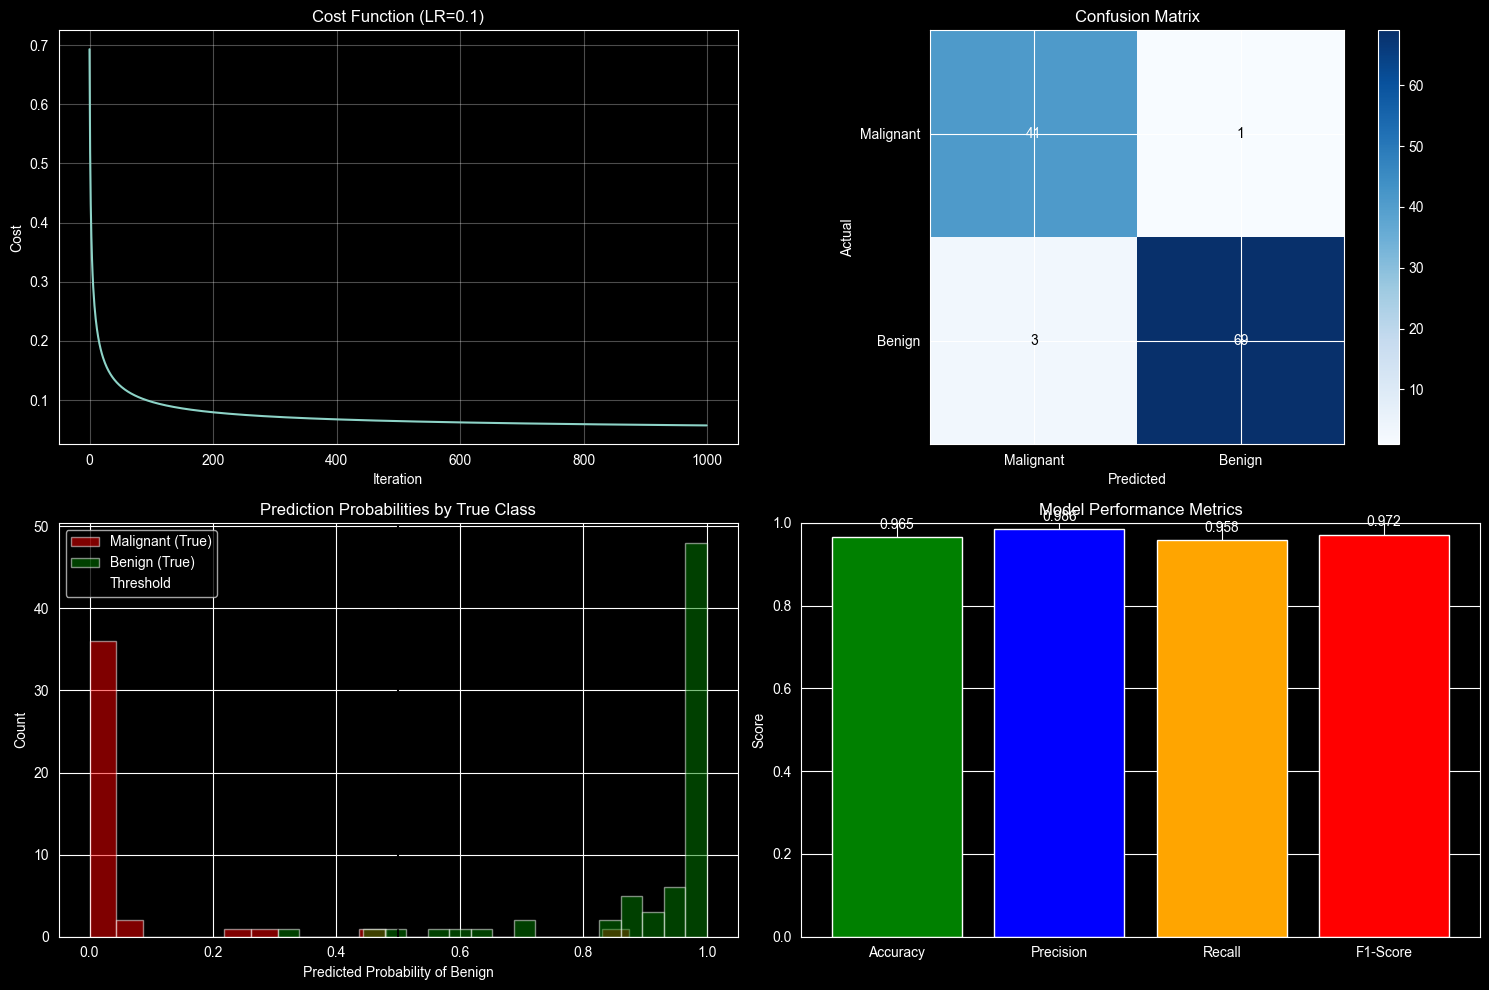


TOP 5 MOST IMPORTANT FEATURES
1. worst texture: -1.0237
2. worst radius: -0.9041
3. worst concave points: -0.8961
4. worst area: -0.8641
5. worst perimeter: -0.8306


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ============================================
# PART 1: LOAD AND EXPLORE REAL DATA
# ============================================

print("=" * 60)
print("BREAST CANCER DATASET")
print("=" * 60)

# Load the dataset
data = load_breast_cancer()
X = data.data  # Features (30 different measurements)
y = data.target  # 0 = malignant, 1 = benign

print(f"\nDataset shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"Classes: 0 (malignant) = {sum(y == 0)}, 1 (benign) = {sum(y == 1)}")

# Create DataFrame for exploration
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
print(f"\nFirst 5 rows:")
print(df.head())

# ============================================
# PART 2: TRAIN/VALIDATION/TEST SPLIT
# ============================================

# Split into train (60%), validation (20%), test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"\nTrain size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

# ============================================
# PART 3: SCALE FEATURES (CRITICAL!)
# ============================================

# Scale features for gradient descent
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ============================================
# PART 4:  LOGISTIC REGRESSION CLASS
# ============================================
def sigmoid(z):
    """Convert z to probability between 0 and 1"""
    return 1 / (1 + np.exp(-z))

def logistic_cost(y_true, y_pred_prob):
    """Calculate log loss"""
    epsilon = 1e-15
    y_pred_prob = np.clip(y_pred_prob, epsilon, 1 - epsilon)
    m = len(y_true)
    cost = -1/m * np.sum(y_true * np.log(y_pred_prob) + (1 - y_true) * np.log(1 - y_pred_prob))
    return cost

class LogisticRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        """
        Train logistic regression using gradient descent

        Parameters:
        X: training features (n_samples, n_features)
        y: training labels (n_samples,)
        """
        n_samples, n_features = X.shape

        # Initialize parameters
        self.weights = np.zeros((n_features, 1))
        self.bias = 0

        for iteration in range(self.n_iterations):
            # Step 1: Calculate linear output (z = w*X + b)
            z = np.dot(X, self.weights) + self.bias

            # Step 2: Convert to probability using sigmoid
            y_pred_prob = sigmoid(z)

            # Step 3: Calculate cost (log loss)
            cost = logistic_cost(y.reshape(-1, 1), y_pred_prob)
            self.cost_history.append(cost)

            # Step 4: Calculate gradients
            # For logistic regression, dw = (1/m) * X.T * (y_pred - y)
            error = y_pred_prob - y.reshape(-1, 1)
            dw = (1/n_samples) * np.dot(X.T, error)
            db = (1/n_samples) * np.sum(error)

            # Step 5: Update parameters (SAME as linear regression!)
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Print progress
            if iteration % 100 == 0:
                print(f"Iteration {iteration:4d}, Cost: {cost:.6f}")

        return self

    def predict_proba(self, X):
        """Return probability predictions"""
        z = np.dot(X, self.weights) + self.bias
        return sigmoid(z)

    def predict(self, X, threshold=0.5):
        """Return class predictions (0 or 1)"""
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

# ============================================
# PART 5: TRAIN WITH DIFFERENT LEARNING RATES
# ============================================

print("\n" + "=" * 60)
print("TRAINING LOGISTIC REGRESSION")
print("=" * 60)

# Try different learning rates to find the best one
learning_rates = [0.1, 0.05, 0.01, 0.005, 0.001]
best_lr = None
best_accuracy = 0

for lr in learning_rates:
    print(f"\nTesting learning rate: {lr}")
    model = LogisticRegressionGD(learning_rate=lr, n_iterations=1000)
    model.fit(X_train_scaled, y_train)

    # Predict on validation set
    y_val_pred = model.predict(X_val_scaled)
    val_accuracy = accuracy_score(y_val, y_val_pred.flatten())
    print(f"Validation accuracy: {val_accuracy:.4f}")
    print(f"Final cost: {model.cost_history[-1]:.6f}")

    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        best_lr = lr
        best_model = model

print(f"\n✅ Best learning rate: {best_lr} with validation accuracy: {best_accuracy:.4f}")

# ============================================
# PART 6: EVALUATE ON TEST SET
# ============================================

y_test_pred = best_model.predict(X_test_scaled)
y_test_pred_proba = best_model.predict_proba(X_test_scaled)

# Calculate metrics
accuracy = accuracy_score(y_test, y_test_pred.flatten())
precision = precision_score(y_test, y_test_pred.flatten())
recall = recall_score(y_test, y_test_pred.flatten())
f1 = f1_score(y_test, y_test_pred.flatten())

print("\n" + "=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred.flatten())
print(f"\nConfusion Matrix:")
print(f"              Predicted")
print(f"              Benign  Malignant")
print(f"Actual Benign    {cm[1,1]:3d}       {cm[1,0]:3d}")
print(f"Actual Malignant {cm[0,1]:3d}       {cm[0,0]:3d}")

# ============================================
# PART 7: VISUALIZE RESULTS
# ============================================

import os
os.makedirs('week3_logistic_regression', exist_ok=True)

plt.figure(figsize=(15, 10))

# Plot 1: Cost history for best model
plt.subplot(2, 2, 1)
plt.plot(best_model.cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title(f'Cost Function (LR={best_lr})')
plt.grid(True, alpha=0.3)

# Plot 2: Confusion Matrix heatmap
plt.subplot(2, 2, 2)
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
tick_marks = [0, 1]
plt.xticks(tick_marks, ['Malignant', 'Benign'])
plt.yticks(tick_marks, ['Malignant', 'Benign'])

# Add text annotations
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black')

# Plot 3: Probability distribution
plt.subplot(2, 2, 3)
plt.hist(y_test_pred_proba[y_test == 0], bins=20, alpha=0.5, label='Malignant (True)', color='red')
plt.hist(y_test_pred_proba[y_test == 1], bins=20, alpha=0.5, label='Benign (True)', color='green')
plt.axvline(x=0.5, color='black', linestyle='--', label='Threshold')
plt.xlabel('Predicted Probability of Benign')
plt.ylabel('Count')
plt.title('Prediction Probabilities by True Class')
plt.legend()

# Plot 4: Metrics bar chart
plt.subplot(2, 2, 4)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]
colors = ['green', 'blue', 'orange', 'red']
plt.bar(metrics, values, color=colors)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Model Performance Metrics')
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.savefig('week3_logistic_regression/breast_cancer_results.png')
plt.show()

# ============================================
# PART 8: FEATURE IMPORTANCE
# ============================================

print("\n" + "=" * 60)
print("TOP 5 MOST IMPORTANT FEATURES")
print("=" * 60)

# Get absolute weights and sort
weights = np.abs(best_model.weights.flatten())
feature_names = data.feature_names
sorted_idx = np.argsort(weights)[::-1]

for i in range(5):
    idx = sorted_idx[i]
    print(f"{i+1}. {feature_names[idx]}: {best_model.weights[idx][0]:.4f}")